# **Sigmoid and Tanh Activation Functions for Image Classification on the MNIST Dataset**

# **Task 1: Introduction**
A neural network model was created in this task to categorise images of the MNIST dataset. It was aimed at creating a model with an input layer, six hidden layers and an output layer and comparing the performance between Sigmoid and Tanh activation functions in the hidden layers.


# **Importing Libraries**

Essential libraries like TensorFlow, NumPy, Matplotlib, Seaborn, and Sklearn are imported for building, training, and evaluating neural networks, along with data visualization.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense
from sklearn.metrics import confusion_matrix


## Loading the MNIST Dataset

The MNIST dataset is loaded using Keras' built-in function tf.keras.datasets.mnist.load_data(). The shapes of the training and testing datasets (x_train, y_train, x_test, y_test) are printed to verify the data structure.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Original x_train shape:", x_train.shape)
print("Original y_train shape:", y_train.shape)
print("Original x_test shape:", x_test.shape)
print("Original y_test shape:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original x_train shape: (60000, 28, 28)
Original y_train shape: (60000,)
Original x_test shape: (10000, 28, 28)
Original y_test shape: (10000,)


# **Normalizing and Reshaping the MNIST Dataset**

The pixel values of x_train and x_test are normalized to a range of 0 to 1 by converting them to float32 and dividing by 255.0. The data is reshaped into a 1D vector of size 784 (28x28 pixels), and the labels are one-hot encoded using Keras' to_categorical method to prepare for multi-class classification.

In [3]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape((x_train.shape[0], 28 * 28))
x_test = x_test.reshape((x_test.shape[0], 28 * 28))

num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print("\nNormalized and Reshaped x_train shape:", x_train.shape)
print("Normalized and Reshaped x_test shape:", x_test.shape)


Normalized and Reshaped x_train shape: (60000, 784)
Normalized and Reshaped x_test shape: (10000, 784)


# **Visualizing Sample Images from the MNIST Dataset**

This code visualizes the first 10 sample images from the MNIST dataset, reshaping them back to 28x28 pixels. The corresponding labels are displayed as titles on each image, showing the digit represented by each image.

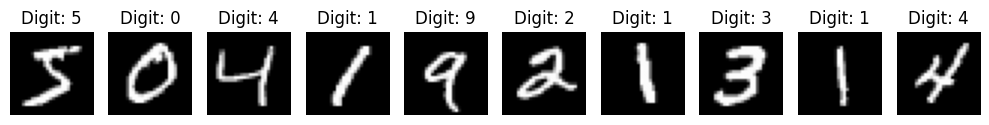

In [4]:
plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    image = x_train[i].reshape(28, 28)
    digit_label = np.argmax(y_train[i])
    plt.imshow(image, cmap='gray')
    plt.title(f"Digit: {digit_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


# **Activation Functions: Sigmoid vs. Tanh**

Sigmoid and Tanh were used to test the impact that these functions have in the model. Sigmoid is common in binary classification as well as output values are 0 to 1; however, it is vulnerable to vanishing gradients when used in deep networks. Data are centred and tanh (between -1 and 1) tends to make the convergence more rapid. The comparative activation of the two functions enables a performance study of the effect of each in the learning process.

# **Model Architecture**

The architecture is composed of 784 input layer nodes (28x28 pixels of the MNIST images), 6 hidden layers with 256 neurons and one output layer with 10 nodes (one representative of each MNIST digit 0-9). The output layer utilised softmax to produce a probability distribution on the 10 classes, which is normal practise in multi-class classification.

# **Refactoring the Sigmoid Model Using the Functional API**

The Sigmoid model is refactored using the Functional API for better flexibility. The model defines an input layer, followed by six hidden layers with Sigmoid activation, and an output layer with Softmax activation. It is then compiled with the Adam optimizer and categorical cross-entropy loss for classification.

In [7]:
input_layer = Input(shape=(x_train.shape[1],))
x = Dense(256, activation='sigmoid')(input_layer)

for _ in range(5):
    x = Dense(256, activation='sigmoid')(x)

output_layer = Dense(num_classes, activation='softmax')(x)

sigmoid_model = Model(inputs=input_layer, outputs=output_layer)

sigmoid_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Sigmoid Model Summary:")
sigmoid_model.summary()


Sigmoid Model Summary:


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,490 (2.03 MB)

 Trainable params: 532,490 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

# **Training Process**

The models were trained over 10 epochs with 128 as the batch size. Adam optimizer was chosen because of its adaptive learning rate and the loss function was categorical cross-entropy. Ten epochs were selected according to the adequate training time and preventing overfitting.


# **Training the Sigmoid Neural Network Model**

The Sigmoid model is trained for 10 epochs with a batch size of 128 on the MNIST dataset. The training process includes both training accuracy and validation accuracy monitoring to evaluate the model's performance on unseen data.

In [8]:
print("Training Sigmoid Model...")
history_sigmoid = sigmoid_model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, y_test)
)
print("Sigmoid Model training complete.")


Training Sigmoid Model...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3460 - loss: 1.7453 - val_accuracy: 0.8731 - val_loss: 0.4715
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8930 - loss: 0.4054 - val_accuracy: 0.9231 - val_loss: 0.2759
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9339 - loss: 0.2368 - val_accuracy: 0.9470 - val_loss: 0.1876
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9492 - loss: 0.1776 - val_accuracy: 0.9502 - val_loss: 0.1701
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9594 - loss: 0.1434 - val_accuracy: 0.9594 - val_loss: 0.1426
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9664 - loss: 0.1169 - val_accuracy: 0.9616 - val_loss: 0.1340
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9715 - loss: 0.1008 - val_accuracy: 0.9662 - val_loss: 0.1246
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9748 - loss:

# **Evaluating the Performance of the Sigmoid Model**

The performance of the Sigmoid model is evaluated on the test dataset, with test loss and test accuracy printed to assess the model’s generalization ability after training.

In [9]:
sigmoid_eval = sigmoid_model.evaluate(x_test, y_test, verbose=0)
print(f"Sigmoid Model - Test Loss: {sigmoid_eval[0]:.4f}")
print(f"Sigmoid Model - Test Accuracy: {sigmoid_eval[1]:.4f}")


Sigmoid Model - Test Loss: 0.1026
Sigmoid Model - Test Accuracy: 0.9723


# **Visualizing Confusion Matrix for the Sigmoid Model**

A confusion matrix is generated to evaluate the Sigmoid model's classification performance. The matrix visualizes the correct and incorrect predictions for each digit (0-9), helping to understand how well the model performs across different classes.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


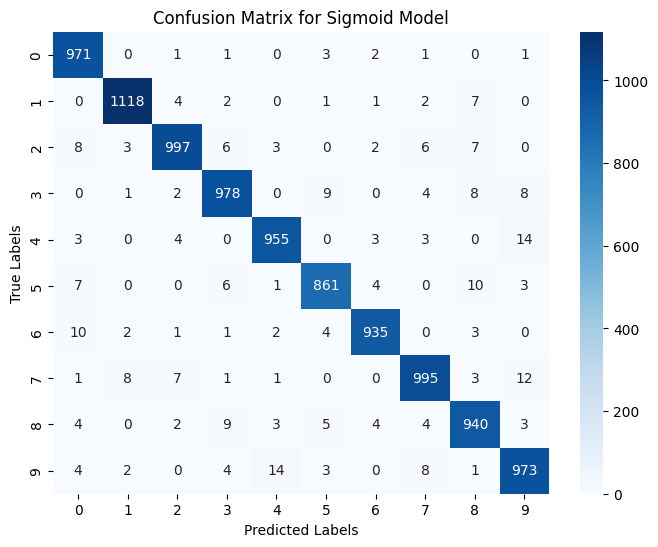

In [11]:
y_pred = sigmoid_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix for Sigmoid Model')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


# **Building the Tanh Neural Network Model**
A Tanh-based Sequential model is created with an input layer, followed by six hidden layers, each using Tanh activation. The output layer consists of 10 nodes with Softmax activation for multi-class classification. The model is compiled with the Adam optimizer and categorical cross-entropy loss.

In [12]:
tanh_model = Sequential()

tanh_model.add(Dense(256, activation='tanh', input_shape=(x_train.shape[1],)))

for _ in range(5):
    tanh_model.add(Dense(256, activation='tanh'))

tanh_model.add(Dense(num_classes, activation='softmax'))

tanh_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Tanh Model Summary:")
tanh_model.summary()

Tanh Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,490 (2.03 MB)

 Trainable params: 532,490 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

# **Training the Tanh Neural Network Model**

The Tanh model is trained for 10 epochs with a batch size of 128 on the MNIST dataset. Training includes both training accuracy and validation accuracy to assess the model’s performance on unseen data.

In [13]:
print("Training Tanh Model...")
history_tanh = tanh_model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, y_test)
)
print("Tanh Model training complete.")

Training Tanh Model...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8631 - loss: 0.4397 - val_accuracy: 0.9514 - val_loss: 0.1625
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9530 - loss: 0.1510 - val_accuracy: 0.9613 - val_loss: 0.1301
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9676 - loss: 0.1062 - val_accuracy: 0.9564 - val_loss: 0.1393
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9718 - loss: 0.0867 - val_accuracy: 0.9705 - val_loss: 0.0986
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9800 - loss: 0.0633 - val_accuracy: 0.9679 - val_loss: 0.1192
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9836 - loss: 0.0521 - val_accuracy: 0.9684 - val_loss: 0.1121
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9823 - loss: 0.0521 - val_accuracy: 0.9741 - val_loss: 0.0902
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9885 - loss: 0.

# **Evaluating the Performance of the Tanh Model**

The Tanh model achieves a test accuracy of 97.66% and test loss of 0.0944, showing strong performance on the test dataset.

In [14]:
tanh_eval = tanh_model.evaluate(x_test, y_test, verbose=0)
print(f"Tanh Model - Test Loss: {tanh_eval[0]:.4f}")
print(f"Tanh Model - Test Accuracy: {tanh_eval[1]:.4f}")


Tanh Model - Test Loss: 0.0944
Tanh Model - Test Accuracy: 0.9766


## Visualizing the Confusion Matrix for the Tanh Model

A confusion matrix for the Tanh model helps visualize the misclassifications and overall performance for each digit class, showing a high accuracy.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


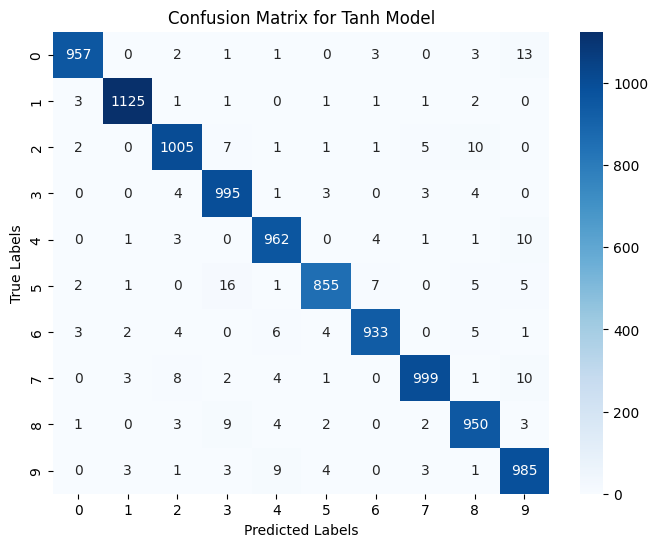

In [28]:
y_pred_tanh = tanh_model.predict(x_test)
y_pred_classes_tanh = np.argmax(y_pred_tanh, axis=1)

cm_tanh = confusion_matrix(np.argmax(y_test, axis=1), y_pred_classes_tanh)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tanh, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix for Tanh Model')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [15]:
print("Sigmoid Model - Test Accuracy:", sigmoid_eval[1])
print("Tanh Model - Test Accuracy:", tanh_eval[1])


Sigmoid Model - Test Accuracy: 0.9722999930381775
Tanh Model - Test Accuracy: 0.9765999913215637


# **Comparison of Test Accuracy Between Sigmoid and Tanh Models**

A bar chart compares test accuracy between the Sigmoid and Tanh models, with the Tanh model showing a slight edge in performance.

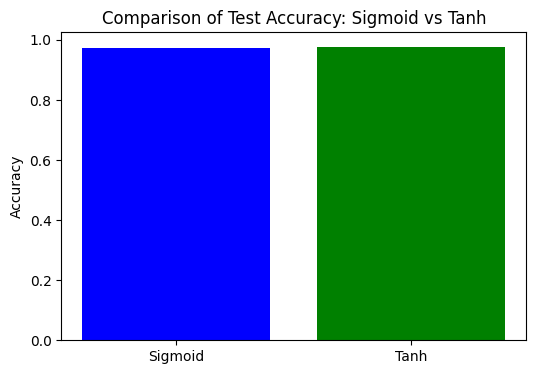

In [19]:
labels = ['Sigmoid', 'Tanh']
accuracies = [sigmoid_eval[1], tanh_eval[1]]

plt.figure(figsize=(6, 4))
plt.bar(labels, accuracies, color=['blue', 'green'])
plt.title('Comparison of Test Accuracy: Sigmoid vs Tanh')
plt.ylabel('Accuracy')
plt.show()

# **Accuracy vs Epochs for Both Models**




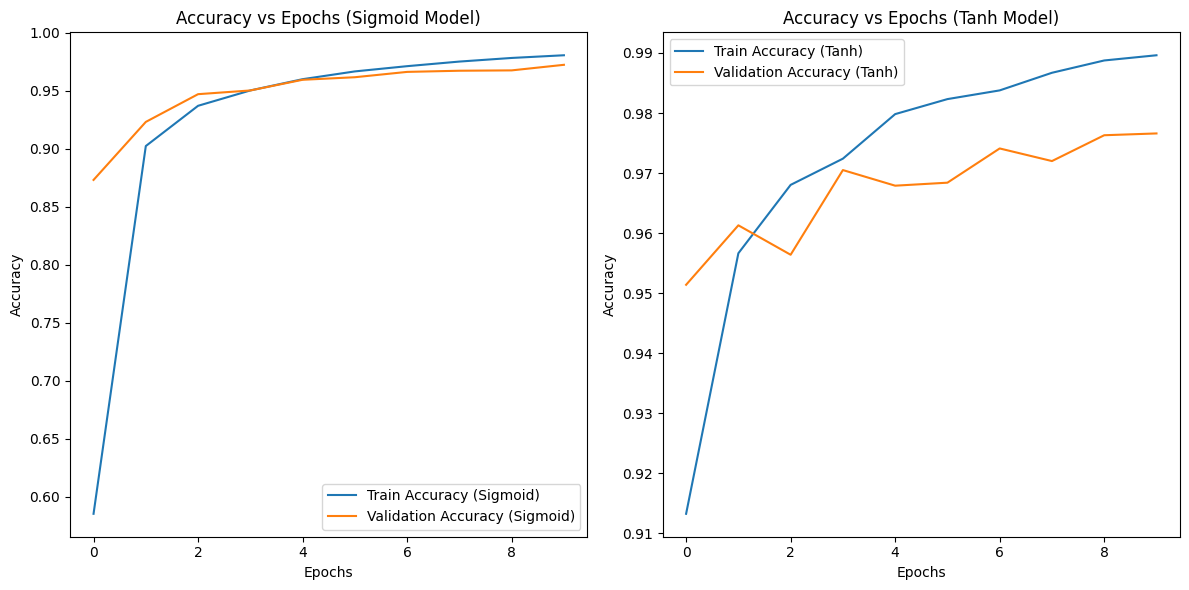

In [22]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_sigmoid.history['accuracy'], label='Train Accuracy (Sigmoid)')
plt.plot(history_sigmoid.history['val_accuracy'], label='Validation Accuracy (Sigmoid)')
plt.title('Accuracy vs Epochs (Sigmoid Model)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tanh.history['accuracy'], label='Train Accuracy (Tanh)')
plt.plot(history_tanh.history['val_accuracy'], label='Validation Accuracy (Tanh)')
plt.title('Accuracy vs Epochs (Tanh Model)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


# **Loss vs Epochs for Both Models**

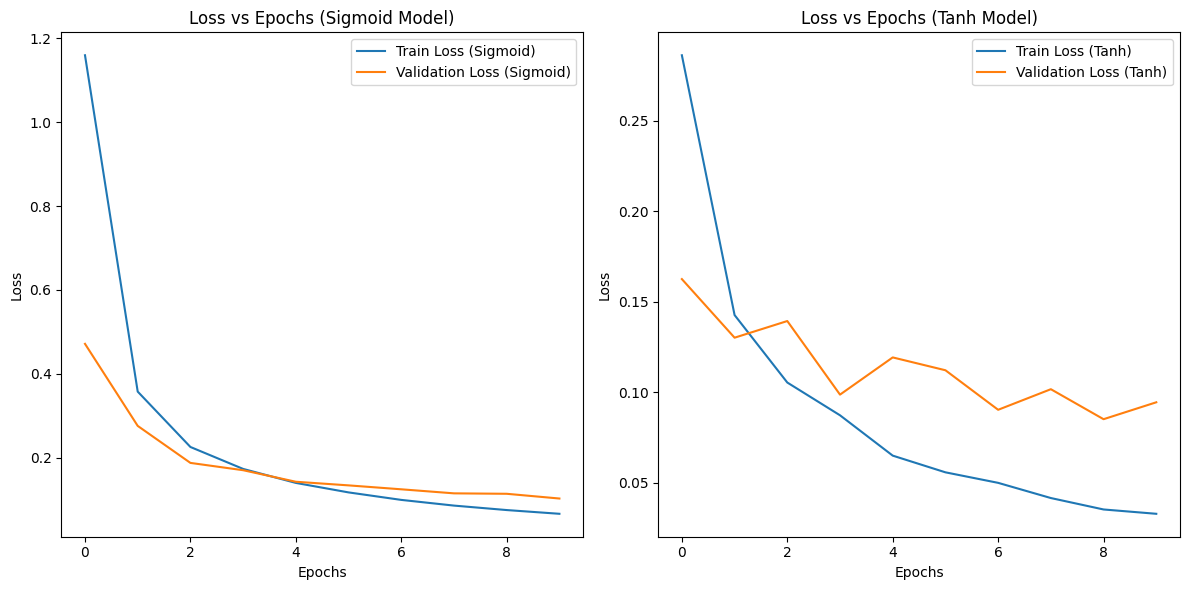

In [23]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_sigmoid.history['loss'], label='Train Loss (Sigmoid)')
plt.plot(history_sigmoid.history['val_loss'], label='Validation Loss (Sigmoid)')
plt.title('Loss vs Epochs (Sigmoid Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tanh.history['loss'], label='Train Loss (Tanh)')
plt.plot(history_tanh.history['val_loss'], label='Validation Loss (Tanh)')
plt.title('Loss vs Epochs (Tanh Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# **Difficulties and Solutions**

The Sigmoid model was slow to converge compared to the Tanh model, which is an expected result since Tanh function can better deal with gradients. It can be improved in the future by applying methods such as Dropout or Batch Normalisation to improve the generalisation of the model and avoid overfitting.

# **Conclusion**

The two models performed well, with the Tanh model slightly ahead of the Sigmoid model, which indicates the need to ensure that the appropriate activation function is chosen in deep neural networks.